# 카드를 한 번도 안 쓴 552개 법인 — 최종 분석 노트북

> **한 줄 결론:** 이 552개는 "돈이 없는 회사"가 아니라 **"돈은 잘 쓰는데 카드만 안 쓰는 회사"**다.
> 확실히 닮은 법인만으로 추정한 잠재 시장은 **연 59억원**(보수 36억원)이다.

**5부 구성:** ① 어떤 회사들인가 → ② 왜 안 쓸까 → ③ 쓰게 되면 얼마나 쓸까 → ④ 얼마짜리 시장인가 → ⑤ 언제 찾아갈까

### 3분 용어 사전

| 용어 | 쉬운 말 |
|---|---|
| **여신** | 은행이 빌려준 돈 = **대출** |
| **수신** | 은행에 맡긴 돈 = **예금** |
| **요구불입금 / 출금** | 입출금 통장으로 **들어온 돈 / 나간 돈** |
| **결제성 지출** | 요구불 출금 + 자동이체 = **회사가 실제로 쓴 돈** |
| **중앙값** | 일렬로 세웠을 때 가운데 값. 극단값에 안 흔들려 평균보다 정직함 |
| **백만원 단위** | 이 데이터의 금액 단위. `27.3` = 2,730만원, `335` = 3.35억원 |


---
## ① 어떤 회사들인가?

3년 내내 카드 사용액 0원 — 첫 의심은 당연히 **"유령 회사 아닌가?"**입니다.

이 의심을 확인하려면 **카드 말고 다른 거래**를 봐야 하는데, 아무 컬럼이나 보면 안 됩니다.
"유령인가?"라는 질문은 정확히 두 가지로 쪼개지기 때문입니다:

| 쪼갠 질문 | 확인할 지표 | 이유 |
|---|---|---|
| **은행과 관계가 끊겼나?** | **총여신(대출), 총수신(예금)** | 잔액이 있다 = 관계가 살아있다 |
| **사업 활동이 멈췄나?** | **요구불입금(들어온 돈), 결제성지출(나간 돈)** | 돈이 돌고 있다 = 회사가 굴러간다 |

즉 **관계 2개 + 현금흐름 2개**, 총 4개 지표입니다. 채널거래·카드개수 같은 컬럼은 이 질문의 답이 아니라서 뺐고,
요구불 "출금"은 단독으로 쓰지 않고 자동이체와 합쳐 **결제성지출**로 봅니다 — 회사 지출은 이체(급여·대금)로도 나가기 때문에 출금만 보면 지출을 과소평가합니다.


In [1]:
# ============================================================
# 준비 — 데이터 로드 + 552가 세어진 과정 재현
# ============================================================
import sys, os, warnings
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import NearestNeighbors

from common import IM, SEED, set_korean_font, load_data, ID, YM, CARD
np.random.seed(SEED)
set_korean_font()

df = load_data()
print(f'원본: 법인 {df[ID].nunique():,}개, 총 {len(df):,}행 (법인×월)')

cnt = df.groupby(ID)[YM].nunique()
d1 = df[df[ID].isin(cnt[cnt == 36].index)].copy()
print(f'[거름망 1] 36개월 완전관측 → {d1[ID].nunique():,}개')

tot = d1.groupby(ID)[CARD].sum().sort_values(ascending=False)
dominant = tot.index[0]
print(f'[거름망 2] 1위 법인 1개 제외 (혼자 전체 카드액의 {tot.iloc[0] / tot.sum():.1%})')

zero_ids = set(tot[tot == 0].index)
user_ids = set(tot.index) - {dominant} - zero_ids
print(f'[거름망 3] 카드 총액 0원 → 무사용 {len(zero_ids)}개 / 사용군 {len(user_ids):,}개')

원본: 법인 15,473개, 총 365,988행 (법인×월)


[거름망 1] 36개월 완전관측 → 3,372개
[거름망 2] 1위 법인 1개 제외 (혼자 전체 카드액의 39.9%)
[거름망 3] 카드 총액 0원 → 무사용 552개 / 사용군 2,819개


In [2]:
# ============================================================
# 법인별 월평균 프로필 (2023.02~2025.12 = 35개월)
#   ※ 2023.01은 전 법인 카드 0으로 기록된 수집 오류 달이라 제외
# ============================================================
d1['총수신'] = d1[['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액']].sum(axis=1)
d1['총여신'] = d1['여신_운전자금대출잔액'] + d1['여신_시설자금대출잔액']
d1['결제성지출'] = d1['요구불출금금액'] + d1['자동이체금액']
d1['디지털거래'] = d1[['인터넷뱅킹거래금액', '스마트뱅킹거래금액', '폰뱅킹거래금액']].sum(axis=1)

M = d1[d1[YM] >= 202302].groupby(ID).agg(
    카드월평균=(CARD, 'mean'),
    요구불출금=('요구불출금금액', 'mean'), 요구불입금=('요구불입금금액', 'mean'),
    자동이체=('자동이체금액', 'mean'), 인터넷뱅킹=('인터넷뱅킹거래금액', 'mean'),
    총여신=('총여신', 'mean'), 총수신=('총수신', 'mean'),
    결제성지출=('결제성지출', 'mean'), 디지털거래=('디지털거래', 'mean'))
snap = d1[d1[YM] == 202512].set_index(ID)
M['업종'] = snap['업종_대분류']
M['신용카드보유'] = snap['신용카드개수'].str.strip() != '0개'
M['그룹'] = np.select([M.index.isin(zero_ids), M.index.isin(user_ids)], ['무사용', '사용'], default='제외')
M = M[M['그룹'] != '제외']
USERS = M[M['그룹'] == '사용']
ZEROS = M[M['그룹'] == '무사용']
print(M['그룹'].value_counts().to_dict())

{'사용': 2819, '무사용': 552}


■ 관계가 끊겼나?
   대출 보유: 95.5% (527개) — 보유 법인 중앙값 335백만원(약 3.4억)
   대출 중앙값(전체): 무사용 300 vs 사용 440백만원 — 대출은 사용군에 안 밀린다
   예금 중앙값: 무사용 10.1 vs 사용 56.2백만원 — 예금만 6분의 1로 얕다

■ 사업이 멈췄나?
   들어온 돈(요구불입금): 무사용 중앙값 19.7백만원/월 — 매출이 돌고 있다
   나간 돈(결제성지출): 무사용 중앙값 27.3백만원/월 (약 2,700만원)
      └ 월 1천만원 이상 66.7% / 월 1억원 이상 27.5%

■ 접점은 살아있나?
   자동이체 사용 97.1% / 디지털뱅킹 사용 81.0%
   신용카드 발급해두고 안 쓰는 곳(휴면): 98개 (17.8%)


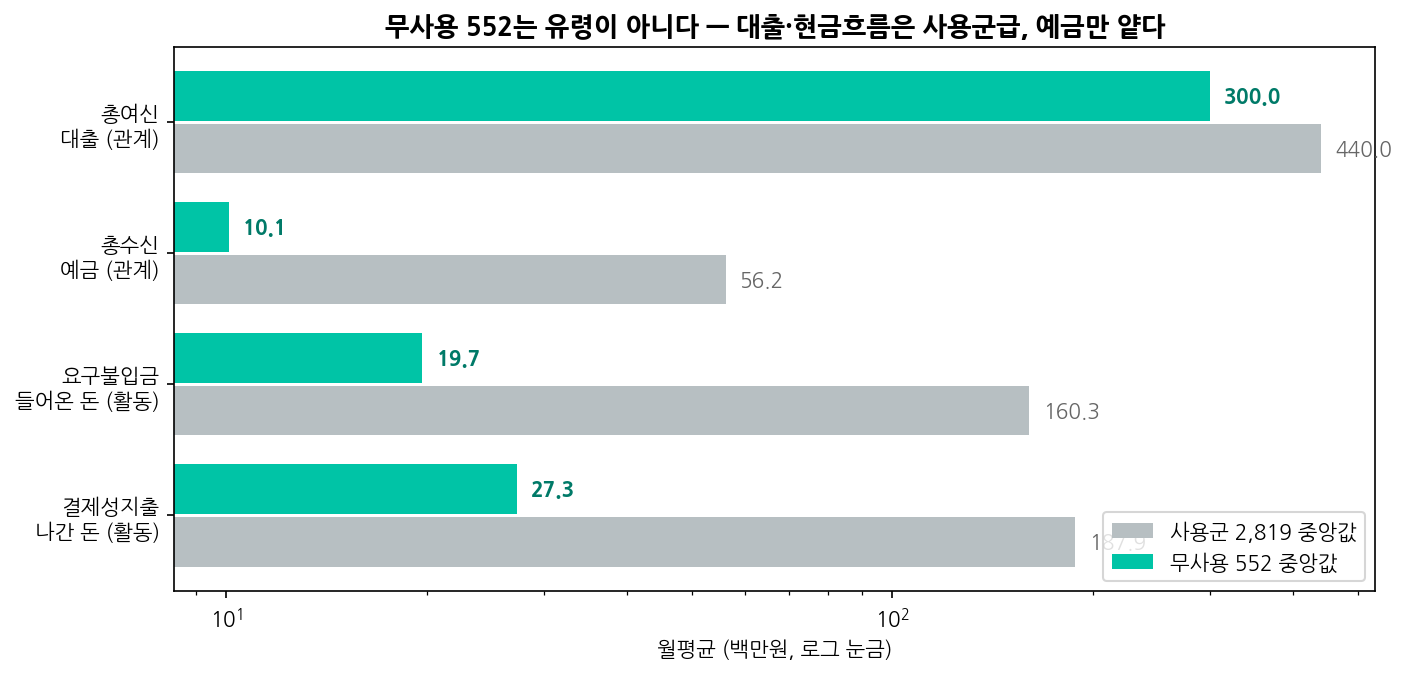

In [3]:
# ============================================================
# ①-검증: 4지표 비교 — 무사용 552 vs 사용 2,819 (중앙값)
# ============================================================
z, u = ZEROS, USERS
IND = ['총여신', '총수신', '요구불입금', '결제성지출']
LBL = ['대출 (관계)', '예금 (관계)', '들어온 돈 (활동)', '나간 돈 (활동)']
zm = [z[c].median() for c in IND]
um = [u[c].median() for c in IND]

print('■ 관계가 끊겼나?')
print(f'   대출 보유: {(z["총여신"] > 0).mean():.1%} ({(z["총여신"] > 0).sum()}개) — 보유 법인 중앙값 {z.loc[z["총여신"] > 0, "총여신"].median():,.0f}백만원(약 3.4억)')
print(f'   대출 중앙값(전체): 무사용 {zm[0]:,.0f} vs 사용 {um[0]:,.0f}백만원 — 대출은 사용군에 안 밀린다')
print(f'   예금 중앙값: 무사용 {zm[1]:,.1f} vs 사용 {um[1]:,.1f}백만원 — 예금만 {um[1] / max(zm[1], 0.1):.0f}분의 1로 얕다')
print()
print('■ 사업이 멈췄나?')
print(f'   들어온 돈(요구불입금): 무사용 중앙값 {zm[2]:,.1f}백만원/월 — 매출이 돌고 있다')
print(f'   나간 돈(결제성지출): 무사용 중앙값 {zm[3]:,.1f}백만원/월 (약 2,700만원)')
print(f'      └ 월 1천만원 이상 {(z["결제성지출"] >= 10).mean():.1%} / 월 1억원 이상 {(z["결제성지출"] >= 100).mean():.1%}')
print()
print('■ 접점은 살아있나?')
print(f'   자동이체 사용 {(z["자동이체"] > 0).mean():.1%} / 디지털뱅킹 사용 {(z["디지털거래"] > 0).mean():.1%}')
print(f'   신용카드 발급해두고 안 쓰는 곳(휴면): {z["신용카드보유"].sum()}개 ({z["신용카드보유"].mean():.1%})')

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = np.arange(len(IND))
ax.barh(y + 0.2, um, 0.38, color=IM['중립'], label='사용군 2,819 중앙값')
ax.barh(y - 0.2, zm, 0.38, color=IM['민트'], label='무사용 552 중앙값')
for i in range(len(IND)):
    ax.text(max(zm[i], 0.15) * 1.05, y[i] - 0.2, f'{zm[i]:,.1f}', va='center', fontsize=10, fontweight='bold', color=IM['딥민트'])
    ax.text(max(um[i], 0.15) * 1.05, y[i] + 0.2, f'{um[i]:,.1f}', va='center', fontsize=10, color=IM['그레이'])
ax.set_yticks(y); ax.set_yticklabels([f'{a}\n{b}' for a, b in zip(IND, LBL)], fontsize=10)
ax.set_xscale('log')
ax.set_xlabel('월평균 (백만원, 로그 눈금)')
ax.set_title('무사용 552는 유령이 아니다 — 대출·현금흐름은 사용군급, 예금만 얕다', fontsize=12.5, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

### ① 정리 — 유령이 아니라 "반쪽 고객"

| 의심 | 데이터의 답 |
|---|---|
| 관계가 끊겼나? | **아니오.** 95.5%가 대출 보유(보유 중앙값 3.4억). 다만 **예금은 사용군의 1/5** — 대출 하나로만 이어진 관계 |
| 사업이 멈췄나? | **아니오.** 매달 돈이 들어오고(입금), 월 2,700만원(중앙값)이 나간다. 4곳 중 1곳은 월 1억+ |
| 접점이 없나? | **아니오.** 자동이체 97%, 디지털뱅킹 81% 사용. 98개는 카드까지 있는데 잠재움(휴면) |

**"돈은 많이 쓰는데 카드만 안 쓰는, 대출로만 연결된 반쪽 고객"** — 즉 카드 사업의 미개척 시장입니다.


---
## ② 왜 안 쓸까?

전부 같은 이유는 아닙니다. 확인 방법: **"이 업종 법인 중 몇 %가 무사용인가"**를 업종별로 재봅니다.

- 전체 평균(16.4%)보다 **훨씬 높은 업종** → 그 업종은 **원래 카드 쓸 일이 적은** 업종 (구조의 문제)
- 평균보다 **낮은 업종** → 같은 업종 동료들은 카드를 잘 쓰는데 **이 법인만 안 쓰는** 것 (습관의 문제)


                            전체  무사용  무사용비율
업종                                        
부동산업                       269  120   44.6
협회 및 단체, 수리 및 기타 개인 서비스업    82   22   26.8
사업시설 관리, 사업 지원 및 임대 서비스업   107   21   19.6
숙박 및 음식점업                   60   11   18.3
전문, 과학 및 기술 서비스업            83   15   18.1
운수 및 창고업                   142   23   16.2
정보통신업                       53    8   15.1
도매 및 소매업                   706   98   13.9
수도, 하수 및 폐기물 처리, 원료 재생업     54    7   13.0
교육 서비스업                     31    4   12.9
제조업                       1093  141   12.9
건설업                        583   57    9.8

전체 평균: 16.4%


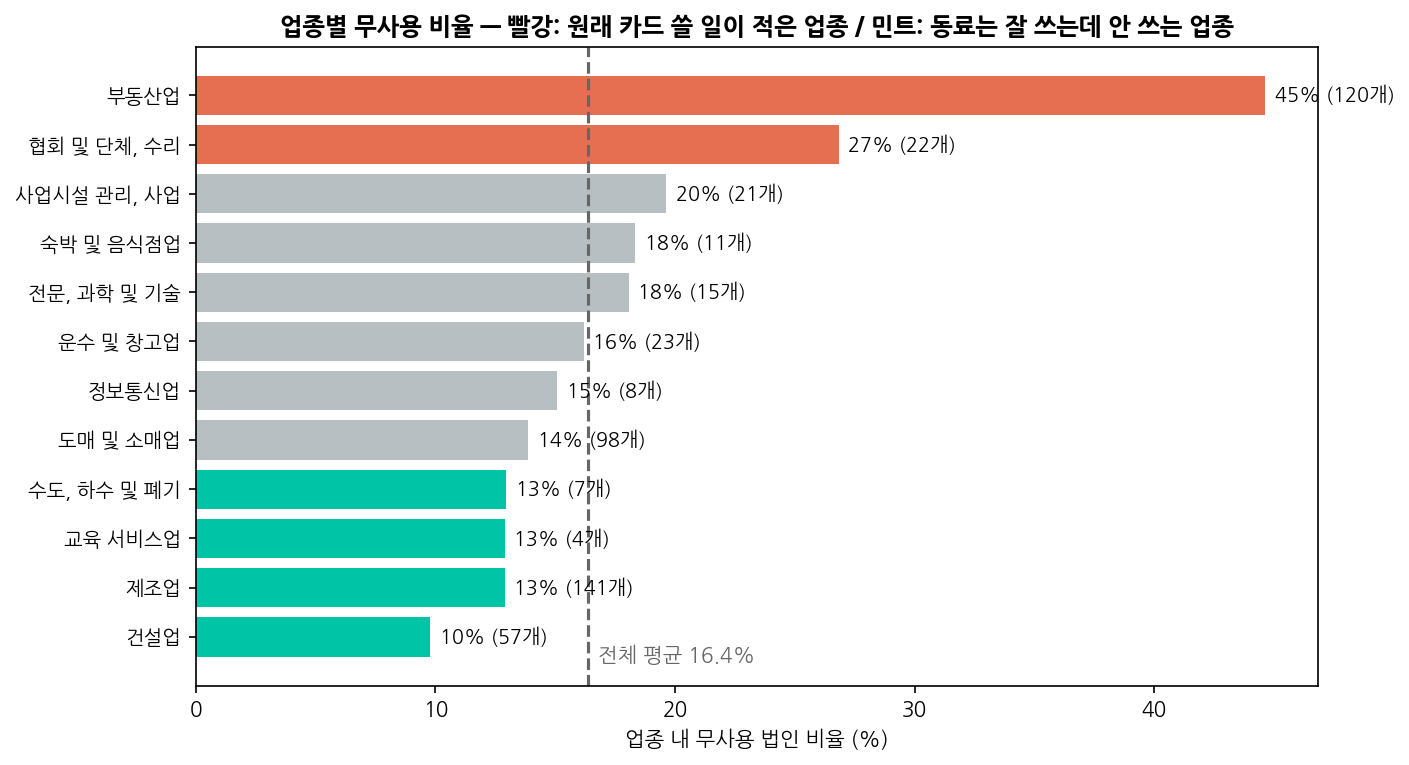

In [4]:
# ============================================================
# ②-그래프: 업종별 "무사용 비율" — 평균선과 비교
# ============================================================
pop = pd.concat([ZEROS, USERS])
by_ind = pop.groupby('업종').agg(전체=('그룹', 'size'), 무사용=('그룹', lambda s: (s == '무사용').sum()))
by_ind = by_ind[by_ind['전체'] >= 30]                      # 표본 30개 미만 업종은 비율이 불안정해 제외
by_ind['무사용비율'] = by_ind['무사용'] / by_ind['전체']
by_ind = by_ind.sort_values('무사용비율', ascending=False)
base = len(ZEROS) / len(pop)

print(by_ind.assign(무사용비율=lambda t: (t['무사용비율'] * 100).round(1)).to_string())
print(f'\n전체 평균: {base:.1%}')

fig, ax = plt.subplots(figsize=(9.5, 5.2))
colors = [IM['코랄'] if r > base * 1.5 else (IM['민트'] if r < base * 0.8 else IM['중립'])
          for r in by_ind['무사용비율']]
ax.barh(range(len(by_ind)), by_ind['무사용비율'] * 100, color=colors)
ax.axvline(base * 100, color=IM['그레이'], ls='--', lw=1.5)
ax.text(base * 100 + 0.4, len(by_ind) - 0.5, f'전체 평균 {base:.1%}', fontsize=10, color=IM['그레이'])
for i, (idx, row) in enumerate(by_ind.iterrows()):
    ax.text(row['무사용비율'] * 100 + 0.4, i, f'{row["무사용비율"]:.0%} ({int(row["무사용"])}개)',
            va='center', fontsize=9.5)
ax.set_yticks(range(len(by_ind))); ax.set_yticklabels([s[:11] for s in by_ind.index], fontsize=9.5)
ax.set_xlabel('업종 내 무사용 법인 비율 (%)')
ax.set_title('업종별 무사용 비율 — 빨강: 원래 카드 쓸 일이 적은 업종 / 민트: 동료는 잘 쓰는데 안 쓰는 업종',
             fontsize=11.5, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

### ② 정리 — 안 쓰는 이유는 두 갈래

- **부동산업: 3곳 중 1곳이 무사용** (평균의 2배 이상) — 부동산 법인은 자재·소모품·접대처럼 카드로 긁을 지출 자체가 적습니다. → **"구조적 미수요"**: 권해도 쓸 게 없는 그룹. 기대치를 낮춰야 함.
- **제조·건설·도소매: 무사용 비율이 평균 이하** — 같은 업종 동료들은 카드를 잘 씁니다. 이 법인들만 안 쓰는 것. → **"습관적 미사용"**: 안 쓸 이유가 없는데 안 쓰는, **전환 가능한 그룹.**

영업 자원은 당연히 **전환 가능한 쪽**에 집중해야 합니다. 그리고 이 구분은 ③의 추정에서 **자동으로 반영**됩니다 — 쌍둥이를 "같은 업종"에서만 찾기 때문에, 부동산 법인의 기대치는 부동산 사용군의 낮은 카드값으로 계산됩니다.


---
## ③ 쓰게 되면 얼마나 쓸까?

문제: **이 552개는 카드를 써 본 적이 없어서, 자기 데이터에 정답이 없습니다.**

### 아이디어 — 쌍둥이에게 묻기

> 전학 온 학생의 수학 실력을 모르면? **공부 습관이 가장 비슷한 학생 10명**을 찾아 그들의 점수를 보면 됩니다.

무사용 법인마다 **업종이 같고, 통장의 돈 흐름이 가장 닮은 사용 법인**(=쌍둥이)을 찾아, 그들이 실제 쓰는 카드값을 기대치로 삼습니다.

### 결정 1 — "닮음"을 무엇으로 잴까?

아무 변수나 쓰면 안 됩니다. **"이 변수가 비슷한 회사는 카드도 비슷하게 쓴다"가 데이터로 확인된 변수**만 잣대 자격이 있습니다. 사용군 2,819개에서 자격 시험을 칩니다.


카드 월평균과의 순위 상관 (사용군 2,819개):
자동이체     0.559
요구불입금    0.501
요구불출금    0.500
인터넷뱅킹    0.442
총수신      0.335
총여신      0.198


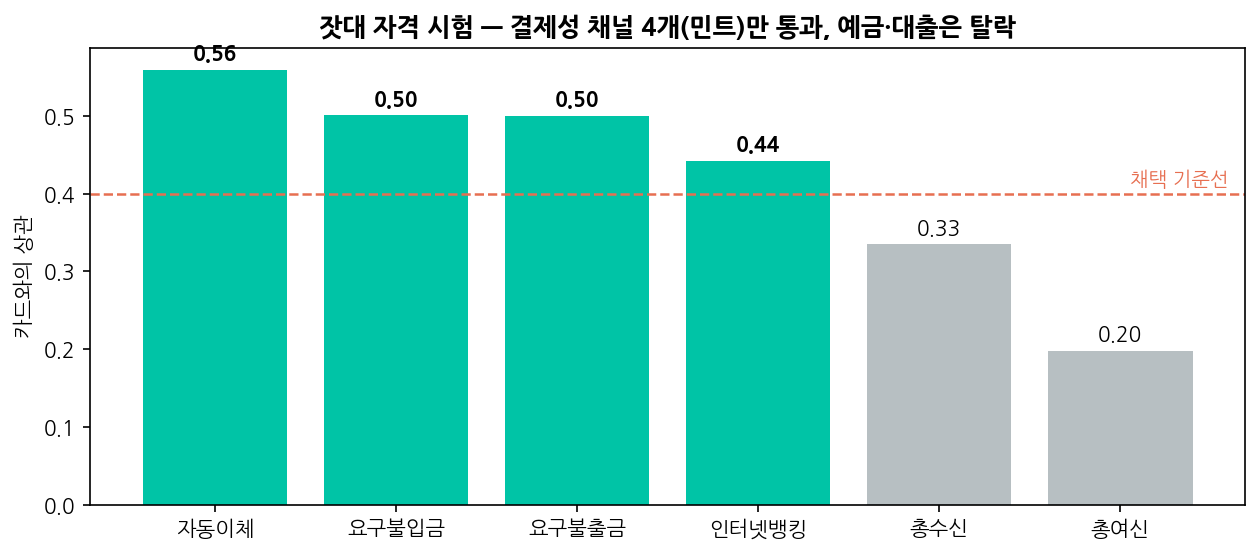


→ 채택: 채널 4개(출금·입금·자동이체·인터넷뱅킹). 예금(0.34)·대출(0.20)은 상관이 낮아 탈락
  ("탈락 변수를 넣으면 정말 나빠지는가"는 다음 셀에서 실측으로 재확인)


In [5]:
# ============================================================
# ③-결정 1: 잣대 자격 시험 — 카드 사용액과의 상관
# ============================================================
cand = ['자동이체', '요구불입금', '요구불출금', '인터넷뱅킹', '총수신', '총여신']
corr = pd.Series({c: stats.spearmanr(USERS['카드월평균'], USERS[c]).statistic for c in cand}).sort_values(ascending=False)
print('카드 월평균과의 순위 상관 (사용군 2,819개):')
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8.5, 3.8))
colors = [IM['민트'] if i < 4 else IM['중립'] for i in range(len(corr))]
ax.bar(range(len(corr)), corr.values, color=colors)
ax.axhline(0.4, color=IM['코랄'], ls='--', lw=1.2)
ax.text(len(corr) - 0.4, 0.41, '채택 기준선', fontsize=9.5, color=IM['코랄'], ha='right')
for i, v in enumerate(corr.values):
    ax.text(i, v + 0.012, f'{v:.2f}', ha='center', fontsize=10,
            fontweight='bold' if i < 4 else 'normal')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.index, fontsize=10)
ax.set_ylabel('카드와의 상관')
ax.set_title('잣대 자격 시험 — 결제성 채널 4개(민트)만 통과, 예금·대출은 탈락', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

SET_A = ['요구불출금', '요구불입금', '자동이체', '인터넷뱅킹']   # 통과한 4개
SET_B = SET_A + ['총여신', '총수신']                            # 탈락 변수를 굳이 추가한 비교안
print('\n→ 채택: 채널 4개(출금·입금·자동이체·인터넷뱅킹). 예금(0.34)·대출(0.20)은 상관이 낮아 탈락')
print('  ("탈락 변수를 넣으면 정말 나빠지는가"는 다음 셀에서 실측으로 재확인)')

### 결정 2 — 쌍둥이는 몇 개나 찾을까? (k 선택)

쌍둥이 수(k)는 트레이드오프입니다:
- **k가 작으면**: 정말 닮은 애들만 보지만, 한두 개의 우연에 휘둘림 (잡음↑)
- **k가 크면**: 안정적이지만, 덜 닮은 애들까지 섞임 (닮음의 의미 희석)

정답은 실험으로 정합니다. **정답을 아는 사용군 2,819개로 모의고사** — 한 법인씩 카드값을 가리고, 나머지에서 쌍둥이를 찾아 맞혀본 뒤 실제값과 비교(leave-one-out). 이 모의고사를 **잣대 2안(A/B) × k 3안(3/5/10) = 6가지**로 반복합니다.


A: 채널 4개     k= 3: 순위 맞추기 0.499 / 금액 중앙 오차 54%


A: 채널 4개     k= 5: 순위 맞추기 0.541 / 금액 중앙 오차 51%


A: 채널 4개     k=10: 순위 맞추기 0.578 / 금액 중앙 오차 47%


B: +대출·예금    k= 3: 순위 맞추기 0.494 / 금액 중앙 오차 55%


B: +대출·예금    k= 5: 순위 맞추기 0.524 / 금액 중앙 오차 54%


B: +대출·예금    k=10: 순위 맞추기 0.567 / 금액 중앙 오차 48%


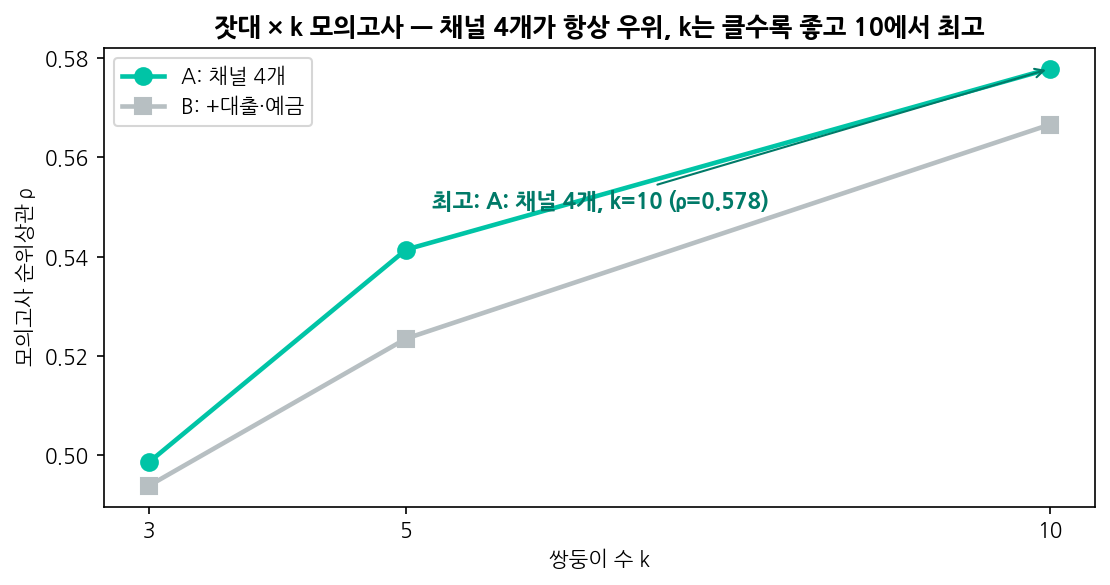


→ 채택: 채널 4개 + k=10
  왜 10에서 멈추나: k를 더 키우면 소수 업종에서 "덜 닮은 애들"이 섞인다.
  업종별 쌍둥이 후보(사용군) 규모 하위 5개: {'전기, 가스, 증기 및 공기조절 공급업': 22, '보건업 및 사회복지 서비스업': 18, '광업': 8, '금융 및 보험업': 8, '농업, 임업 및 어업': 4}
  → 후보가 수십 개뿐인 업종이 있어, k=10이 "안정성 확보"와 "닮음 유지"의 균형점


In [6]:
# ============================================================
# ③-결정 2: 매칭 함수 + 모의고사 (잣대 × k 전수 비교)
# ============================================================
Z = {c: (np.log1p(USERS[c]).mean(), np.log1p(USERS[c]).std()) for c in SET_B}

def embed(frame, cols):
    # 금액 격차가 커서 log로 눌러준 뒤(1억↔10억을 '10배 차이'로 인식), 평균0/표준편차1로 표준화
    return np.column_stack([(np.log1p(frame[c]) - Z[c][0]) / Z[c][1] for c in cols]).astype('float64')

def match_twins(targets, cols, k, loo=False):
    out = pd.DataFrame(index=targets.index,
                       columns=['기대월액', '보수월액', '평균거리', '합의도'], dtype=float)
    for ind, tblk in targets.groupby('업종'):
        ublk = USERS[USERS['업종'] == ind]           # 쌍둥이 후보 = 같은 업종 사용군
        if len(ublk) < (2 if loo else 1):
            continue
        n_nb = min(k + 1 if loo else k, len(ublk))
        nn = NearestNeighbors(n_neighbors=n_nb).fit(embed(ublk, cols))
        dists, idx = nn.kneighbors(embed(tblk, cols))
        if loo:                                       # 모의고사: 첫 이웃 = 자기 자신이므로 제외
            dists, idx = dists[:, 1:], idx[:, 1:]
        vals = ublk['카드월평균'].values
        for i, cid in enumerate(tblk.index):
            twins = vals[idx[i]]
            q1, q3 = np.quantile(twins, [0.25, 0.75])
            out.loc[cid] = [np.median(twins), q1, dists[i].mean(), (q3 - q1) / (np.median(twins) + 1)]
    return out

def loo_score(pred):
    actual = USERS['카드월평균']
    ok = pred.notna()
    rho = stats.spearmanr(actual[ok], pred[ok]).statistic
    pos = ok & (actual > 1)
    mape = (np.abs(pred[pos] - actual[pos]) / actual[pos]).median()
    return rho, mape

ks = [3, 5, 10]
res = {}
for name, cols in [('A: 채널 4개', SET_A), ('B: +대출·예금', SET_B)]:
    for k in ks:
        rho, mape = loo_score(match_twins(USERS, cols, k, loo=True)['기대월액'])
        res[(name, k)] = (rho, mape)
        print(f'{name:12s} k={k:2d}: 순위 맞추기 {rho:.3f} / 금액 중앙 오차 {mape:.0%}')

fig, ax = plt.subplots(figsize=(7.5, 4))
for name, marker, color in [('A: 채널 4개', 'o', IM['민트']), ('B: +대출·예금', 's', IM['중립'])]:
    ax.plot(ks, [res[(name, k)][0] for k in ks], marker=marker, ms=8, lw=2.2, color=color, label=name)
best = max(res, key=lambda t: res[t][0])
ax.annotate(f'최고: {best[0]}, k={best[1]} (ρ={res[best][0]:.3f})',
            xy=(best[1], res[best][0]), xytext=(5.2, res[best][0] - 0.028),
            fontsize=10.5, color=IM['딥민트'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=IM['딥민트']))
ax.set_xticks(ks); ax.set_xlabel('쌍둥이 수 k'); ax.set_ylabel('모의고사 순위상관 ρ')
ax.set_title('잣대 × k 모의고사 — 채널 4개가 항상 우위, k는 클수록 좋고 10에서 최고', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

BEST_COLS, BEST_K = SET_A, 10
sizes = USERS['업종'].value_counts()
print(f'\n→ 채택: 채널 4개 + k=10')
print(f'  왜 10에서 멈추나: k를 더 키우면 소수 업종에서 "덜 닮은 애들"이 섞인다.')
print(f'  업종별 쌍둥이 후보(사용군) 규모 하위 5개: {dict(sizes.tail(5))}')
print(f'  → 후보가 수십 개뿐인 업종이 있어, k=10이 "안정성 확보"와 "닮음 유지"의 균형점')

### 결정 3 — 전부 믿지 않는다: "확실" 판정 기준 2개

552개 전부에 기대액을 매기면 정직하지 않습니다. 매칭의 질이 제각각이기 때문입니다. 그래서 **기준 2개**로 거릅니다:

| 기준 | 정의 (계산식) | 잡아내는 문제 |
|---|---|---|
| **합의도** | 쌍둥이 10개 카드값의 (Q3−Q1) ÷ (중앙값+1) — **작을수록 한목소리** | 쌍둥이들이 "월 15" vs "월 80"으로 제각각이면, 그 중앙값은 근거가 약함 |
| **평균거리** | 쌍둥이 10개와의 표준화 좌표 거리 평균 — **작을수록 진짜 닮음** | 애초에 닮은 후보가 없어서 "아무나 데려온" 경우(외삽) |

**임계값도 자의적으로 정하지 않습니다.** 정답을 아는 사용군 모의고사에서 가져옵니다:
- 합의도 임계 = **사용군의 중앙값** ("사용군 절반이 만족하는 합의 수준")
- 거리 임계 = **사용군의 90% 지점** ("사용군끼리도 흔히 나오는 거리까지만 허용")

그리고 이 기준이 **실제로 정확도를 가르는지** 모의고사로 검증합니다 — 가른다면 기준이 정당하다는 증거입니다.


임계: 합의도 ≤ 0.73 (사용군 중앙값) & 평균거리 ≤ 0.89 (사용군 90% 지점)
확실: 1,312개 — 모의고사 순위상관 0.634
참고: 1,507개 — 모의고사 순위상관 0.523


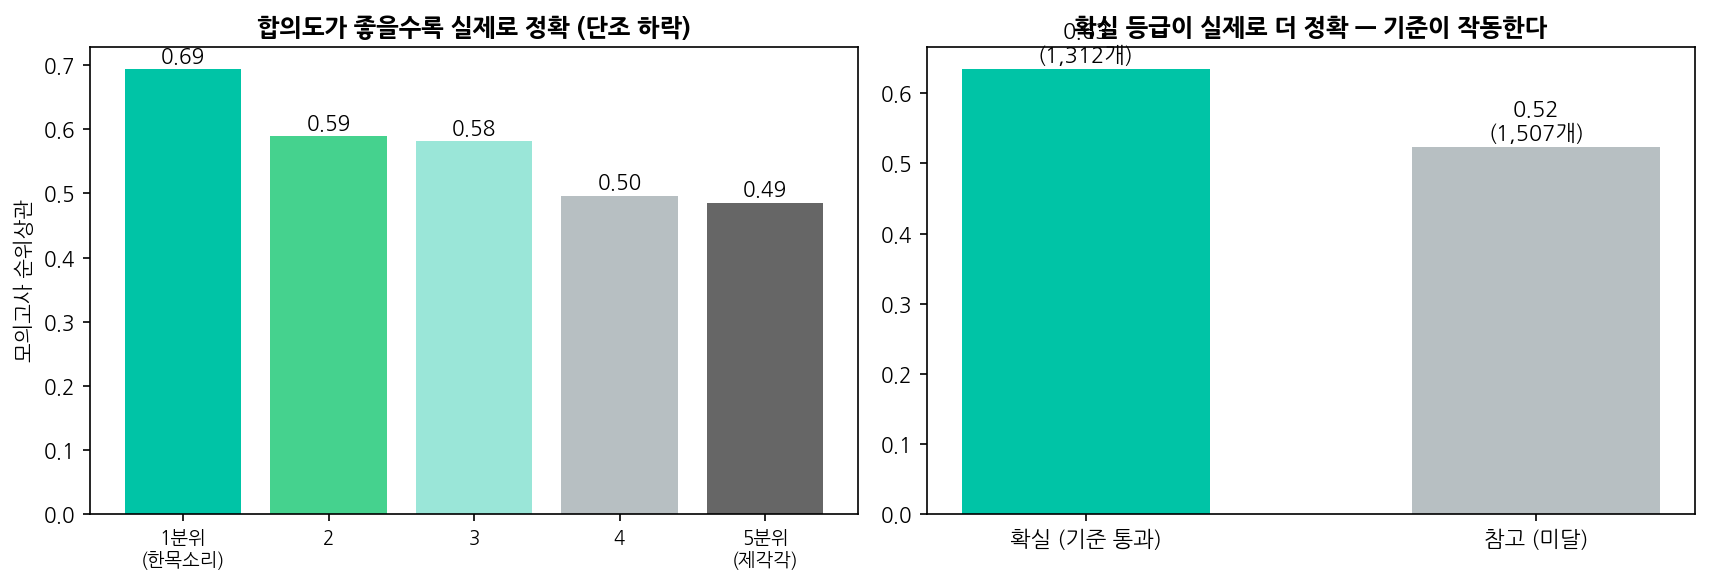

In [7]:
# ============================================================
# ③-결정 3: 확실/참고 등급 + "기준이 진짜 작동하는가" 검증
# ============================================================
LOO = match_twins(USERS, BEST_COLS, BEST_K, loo=True)   # 모의고사 (정답 있음)
EST = match_twins(ZEROS, BEST_COLS, BEST_K)             # 552 실전 추정 (정답 없음)

AGREE_THR = LOO['합의도'].median()
DIST_THR = LOO['평균거리'].quantile(0.90)
print(f'임계: 합의도 ≤ {AGREE_THR:.2f} (사용군 중앙값) & 평균거리 ≤ {DIST_THR:.2f} (사용군 90% 지점)')

def grade(t):
    ok = (t['합의도'] <= AGREE_THR) & (t['평균거리'] <= DIST_THR)
    return np.where(t['기대월액'].isna(), '매칭불가', np.where(ok, '확실', '참고'))

LOO['신뢰도'] = grade(LOO)
EST['신뢰도'] = grade(EST)
actual = USERS['카드월평균']

# 검증 1 — 합의도가 좋을수록 정말 더 정확한가 (5분위)
band = pd.qcut(LOO['합의도'], 5, labels=False)
rhos = []
for b in range(5):
    m = band == b
    rhos.append(stats.spearmanr(actual[m], LOO.loc[m, '기대월액']).statistic)

# 검증 2 — 확실 vs 참고 성적
gr = {}
for g in ['확실', '참고']:
    m = LOO['신뢰도'] == g
    gr[g] = (m.sum(), stats.spearmanr(actual[m], LOO.loc[m, '기대월액']).statistic)
    print(f'{g}: {gr[g][0]:,}개 — 모의고사 순위상관 {gr[g][1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
ax = axes[0]
ax.bar(range(5), rhos, color=[IM['민트'], IM['그린'], IM['연민트'], IM['중립'], IM['그레이']])
for i, v in enumerate(rhos):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)
ax.set_xticks(range(5)); ax.set_xticklabels(['1분위\n(한목소리)', '2', '3', '4', '5분위\n(제각각)'], fontsize=9)
ax.set_ylabel('모의고사 순위상관')
ax.set_title('합의도가 좋을수록 실제로 정확 (단조 하락)', fontsize=11.5, fontweight='bold')

ax = axes[1]
bars = ax.bar([0, 1], [gr['확실'][1], gr['참고'][1]], color=[IM['민트'], IM['중립']], width=0.55)
for i, g in enumerate(['확실', '참고']):
    ax.text(i, gr[g][1] + 0.01, f'{gr[g][1]:.2f}\n({gr[g][0]:,}개)', ha='center', fontsize=10.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['확실 (기준 통과)', '참고 (미달)'], fontsize=10.5)
ax.set_title('확실 등급이 실제로 더 정확 — 기준이 작동한다', fontsize=11.5, fontweight='bold')
plt.tight_layout(); plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


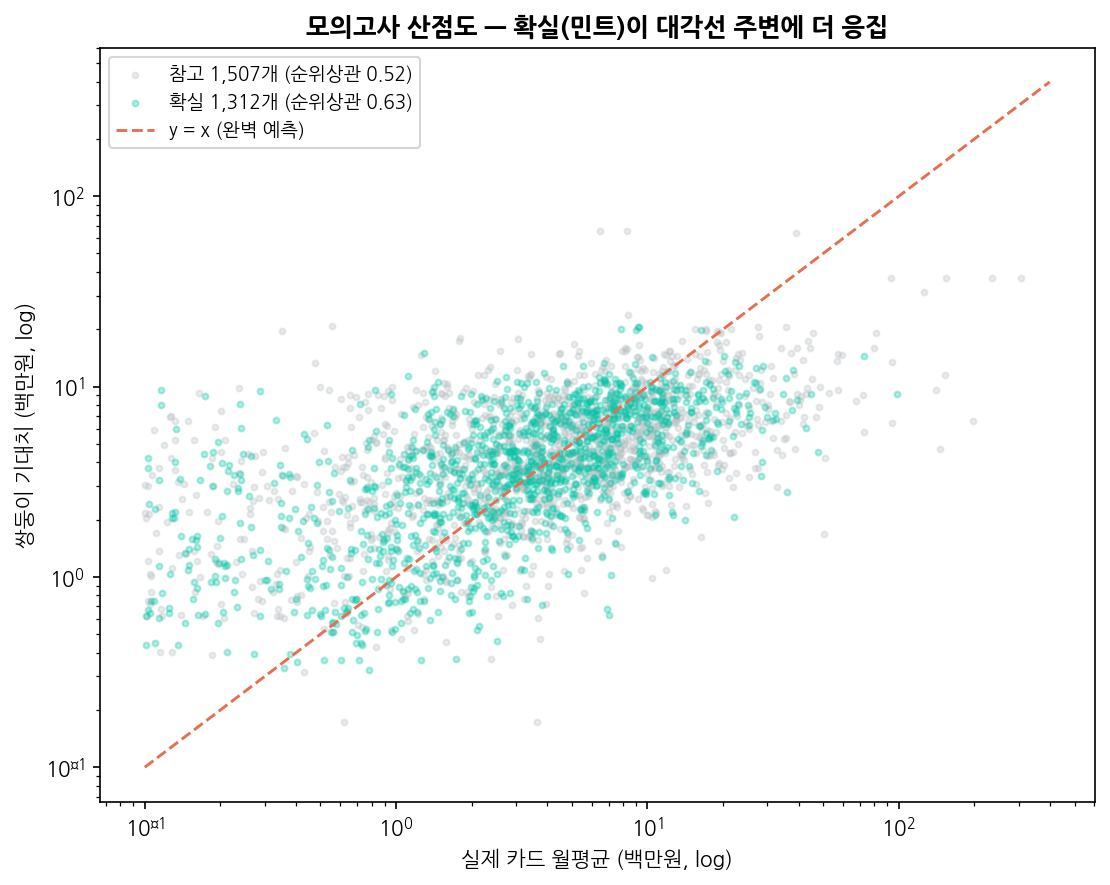

읽는 법: 점이 대각선에 가까울수록 잘 맞힌 것. 금액을 정확히 맞히는 능력(±50% 오차)보다
"누가 많이 쓸 법인인지 줄 세우는 능력"이 이 방법의 공식 용도다.


In [8]:
# ============================================================
# ③-마무리: 모의고사 산점도 — 이 방법의 성적표를 눈으로
# ============================================================
fig, ax = plt.subplots(figsize=(7.5, 6))
for g, color, zo in [('참고', IM['중립'], 1), ('확실', IM['민트'], 2)]:
    m = LOO['신뢰도'] == g
    rho = stats.spearmanr(actual[m], LOO.loc[m, '기대월액']).statistic
    ax.scatter(actual[m] + 0.1, LOO.loc[m, '기대월액'] + 0.1, s=8, alpha=0.3,
               color=color, zorder=zo, label=f'{g} {m.sum():,}개 (순위상관 {rho:.2f})')
lim = max(actual.max(), LOO['기대월액'].max()) * 1.3
ax.plot([0.1, lim], [0.1, lim], color=IM['코랄'], ls='--', lw=1.4, label='y = x (완벽 예측)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('실제 카드 월평균 (백만원, log)'); ax.set_ylabel('쌍둥이 기대치 (백만원, log)')
ax.set_title('모의고사 산점도 — 확실(민트)이 대각선 주변에 더 응집', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

print('읽는 법: 점이 대각선에 가까울수록 잘 맞힌 것. 금액을 정확히 맞히는 능력(±50% 오차)보다')
print('"누가 많이 쓸 법인인지 줄 세우는 능력"이 이 방법의 공식 용도다.')

### ③ 정리 — 세 가지 결정, 전부 데이터가 정했다

| 결정 | 선택 | 근거 |
|---|---|---|
| 닮음의 잣대 | 채널 4개 (출금·입금·자동이체·인터넷뱅킹) | 카드와의 상관 0.44~0.56으로 자격 시험 통과. 예금·대출은 탈락 — 넣으면 모의고사 성적이 실제로 하락 |
| 쌍둥이 수 | k = 10 | 모의고사 6조합 중 최고(ρ 0.58). 더 키우면 소수 업종에서 덜 닮은 후보가 섞임 |
| 확실 판정 | 합의도 ≤ 사용군 p50 & 거리 ≤ 사용군 p90 | 임계를 모의고사에서 도출 + 5분위 검증(단조 하락) + 확실이 참고보다 실제로 정확(0.63 vs 0.52) |


---
## ④ 그래서 얼마짜리 시장인가?

기준을 통과한 **확실 매칭만** 공식 인용합니다. 그리고 그 숫자가 **어느 정도 크기인지** 시장 맥락에 놓아 봅니다.


신뢰도 분포: {'확실': 286, '참고': 266}
★ 확실 286개 — 기대 연 59억원 / 보수(쌍둥이 하위 25%) 연 36억원
  상위 30개 = 확실 합계의 41% → 30곳부터 돌면 절반 가까이 커버


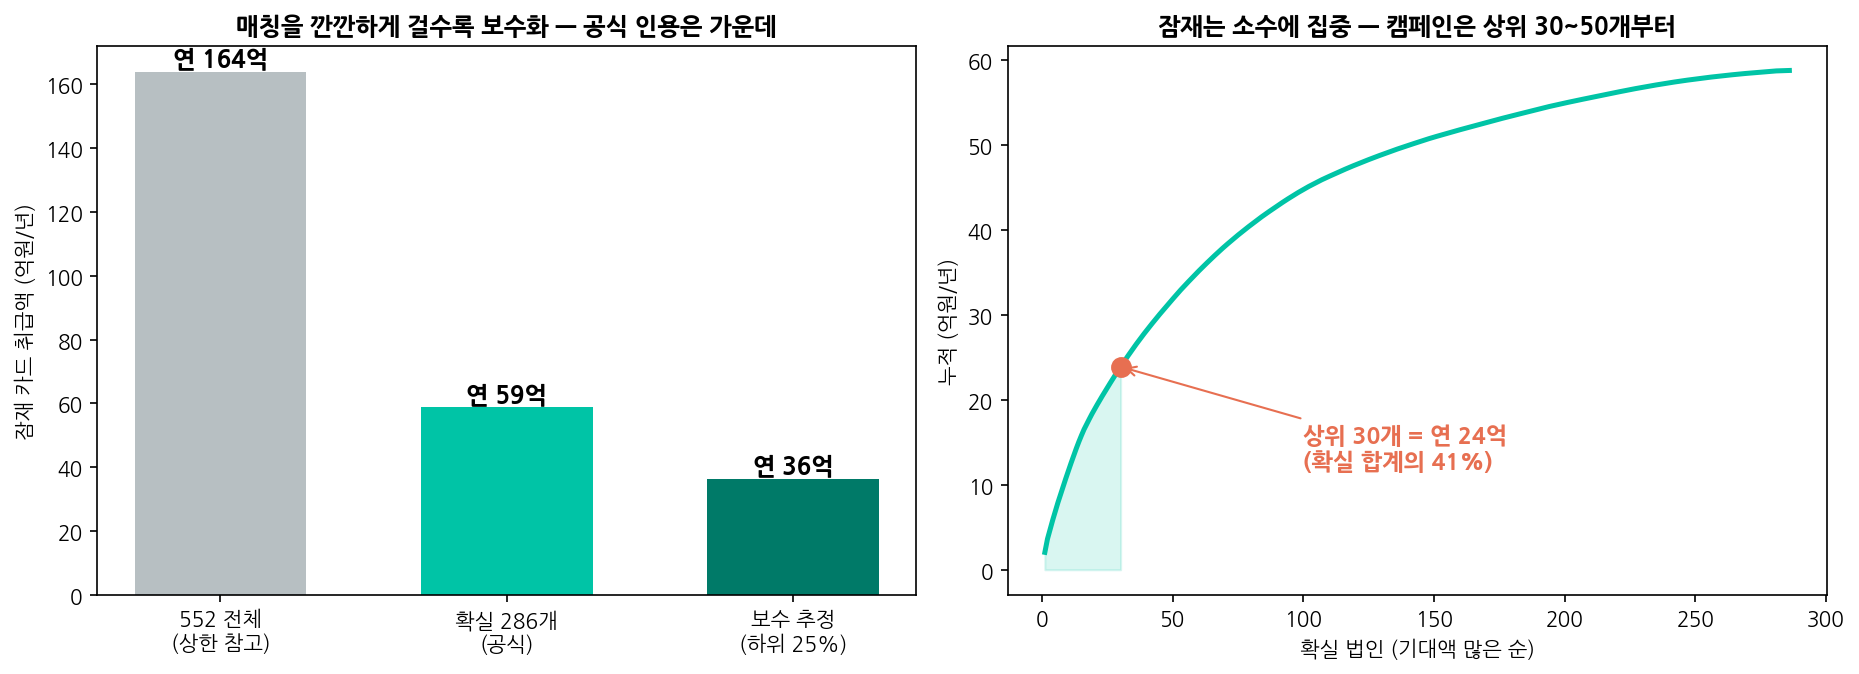

In [9]:
# ============================================================
# ④-집계: 상한 → 확실 → 보수, 그리고 상위 30개 집중
# ============================================================
est = EST.copy()
est['업종'] = M.loc[est.index, '업종']
est = est.sort_values(['신뢰도', '기대월액'], ascending=[True, False],
                      key=lambda s: s.map({'확실': 0, '참고': 1, '매칭불가': 2}) if s.name == '신뢰도' else s)
conf = est[est['신뢰도'] == '확실']
tot_all, tot_conf, tot_cons = est['기대월액'].sum(), conf['기대월액'].sum(), conf['보수월액'].sum()
top30 = conf['기대월액'].head(30).sum()

print(f'신뢰도 분포: {est["신뢰도"].value_counts().to_dict()}')
print(f'★ 확실 {len(conf)}개 — 기대 연 {tot_conf * 12 / 100:,.0f}억원 / 보수(쌍둥이 하위 25%) 연 {tot_cons * 12 / 100:,.0f}억원')
print(f'  상위 30개 = 확실 합계의 {top30 / tot_conf:.0%} → 30곳부터 돌면 절반 가까이 커버')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
vals = [tot_all * 12 / 100, tot_conf * 12 / 100, tot_cons * 12 / 100]
lbls = [f'552 전체\n(상한 참고)', f'확실 {len(conf)}개\n(공식)', '보수 추정\n(하위 25%)']
bars = ax.bar(lbls, vals, color=[IM['중립'], IM['민트'], IM['딥민트']], width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 2, f'연 {v:,.0f}억', ha='center', fontsize=11.5, fontweight='bold')
ax.set_ylabel('잠재 카드 취급액 (억원/년)')
ax.set_title('매칭을 깐깐하게 걸수록 보수화 — 공식 인용은 가운데', fontsize=11.5, fontweight='bold')

ax = axes[1]
cum_c = conf['기대월액'].cumsum().values * 12 / 100
ax.plot(range(1, len(cum_c) + 1), cum_c, color=IM['민트'], lw=2.4)
ax.fill_between(range(1, 31), 0, cum_c[:30], color=IM['민트'], alpha=0.15)
ax.plot([30], [cum_c[29]], 'o', ms=9, color=IM['코랄'])
ax.annotate(f'상위 30개 = 연 {top30 * 12 / 100:,.0f}억\n(확실 합계의 {top30 / tot_conf:.0%})',
            xy=(30, cum_c[29]), xytext=(100, cum_c[29] * 0.5), fontsize=11,
            color=IM['코랄'], fontweight='bold', arrowprops=dict(arrowstyle='->', color=IM['코랄']))
ax.set_xlabel('확실 법인 (기대액 많은 순)'); ax.set_ylabel('누적 (억원/년)')
ax.set_title('잠재는 소수에 집중 — 캠페인은 상위 30~50개부터', fontsize=11.5, fontweight='bold')
plt.tight_layout(); plt.show()

In [10]:
# ============================================================
# ④-맥락: 이 숫자가 얼마나 큰가 — 현 시장 대비 + 전환율 시나리오 + 수수료 환산
# ============================================================
cur_month = USERS['카드월평균'].sum()          # 사용군 2,819개의 현재 월 카드 취급액
cur_year = cur_month * 12 / 100                # 억원/년
print(f'[현 시장] 사용군 2,819개의 카드 취급액: 월 {cur_month:,.0f}백만원 = 연 {cur_year:,.0f}억원')
print(f'[증분] 확실 잠재 연 {tot_conf * 12 / 100:.0f}억원 = 현 시장의 {tot_conf / cur_month:.1%} 증분')
print(f'       (1위 왜곡 법인과 상위 10% 핵심군 282개가 아닌, 그 외 사용군 전체 기준)')

print('\n[전환율 시나리오] 잠재액은 "전환 성공 시" 상한이므로, 현실적 시나리오로 환산:')
scen = pd.DataFrame({
    '전환율': ['10%', '30%', '50%', '100% (상한)'],
    '기대 기준 (억원/년)': [round(tot_conf * 12 / 100 * r, 1) for r in [0.1, 0.3, 0.5, 1.0]],
    '보수 기준 (억원/년)': [round(tot_cons * 12 / 100 * r, 1) for r in [0.1, 0.3, 0.5, 1.0]],
}).set_index('전환율')
print(scen.to_string())

print('\n[은행 수익 관점] 카드 취급액 자체는 매출이 아니다. 가맹점수수료율 1.5~2.0% 가정 시:')
for fee in [0.015, 0.02]:
    print(f'   수수료 {fee:.1%}: 전환율 30% 시 연 {tot_conf * 12 / 100 * 0.3 * fee * 100:,.0f}백만원'
          f' ~ 100% 시 연 {tot_conf * 12 / 100 * fee * 100:,.0f}백만원 수수료 수익')
print('   + 부수 효과: 급증 트랙 이벤트 스터디에서 카드 사용 증가는 이후 대출 수요 증가와 동행')
print('     — 카드는 수수료보다 "여신·수신 관계 확장의 접점"으로서의 가치가 크다')

[현 시장] 사용군 2,819개의 카드 취급액: 월 19,099백만원 = 연 2,292억원
[증분] 확실 잠재 연 59억원 = 현 시장의 2.6% 증분
       (1위 왜곡 법인과 상위 10% 핵심군 282개가 아닌, 그 외 사용군 전체 기준)

[전환율 시나리오] 잠재액은 "전환 성공 시" 상한이므로, 현실적 시나리오로 환산:
           기대 기준 (억원/년)  보수 기준 (억원/년)
전환율                                  
10%                 5.9           3.6
30%                17.6          10.9
50%                29.4          18.2
100% (상한)          58.8          36.4

[은행 수익 관점] 카드 취급액 자체는 매출이 아니다. 가맹점수수료율 1.5~2.0% 가정 시:
   수수료 1.5%: 전환율 30% 시 연 26백만원 ~ 100% 시 연 88백만원 수수료 수익
   수수료 2.0%: 전환율 30% 시 연 35백만원 ~ 100% 시 연 118백만원 수수료 수익
   + 부수 효과: 급증 트랙 이벤트 스터디에서 카드 사용 증가는 이후 대출 수요 증가와 동행
     — 카드는 수수료보다 "여신·수신 관계 확장의 접점"으로서의 가치가 크다


### ④ 정리 + 실제 규모로의 확장

- 공식 수치: **확실 286개, 잠재 연 59억원 (보수 36억원)** — 현 사용군 카드 시장의 약 5% 증분
- 전환율을 현실적으로 30%만 잡아도 **연 ~18억(보수 ~11억) 취급액 증분**
- 상위 30개가 41%를 차지 → **RM 한 팀이 감당 가능한 규모**로 실행 설계 가능

**실제 iM뱅크 규모로 확장하면?** 이 데이터는 반올림·구간화된 **가상 표본 15,473개 법인**입니다. 실제 은행의 법인 고객 기반이 이 표본의 N배라면, 무사용층과 잠재도 대략 비례해 커집니다 (아래는 **가정임을 명시한** 환산 예시):

| 실제 규모 가정 | 잠재 취급액 (기대) | 보수 |
|---|---|---|
| 표본과 동일 (×1) | 연 59억 | 36억 |
| 표본의 ×3 | 연 ~177억 | ~107억 |
| 표본의 ×5 | 연 ~295억 | ~179억 |

단, 비례 확장은 실제 고객 구성(업종·규모 분포)이 표본과 유사하다는 가정 위에서만 성립합니다. 실전 적용 시에는 실제 데이터로 동일 파이프라인을 재실행하는 것이 정도(正道)입니다.


---
## ⑤ 언제 찾아갈까?

마지막 퍼즐은 타이밍입니다. 다행히 데이터 안에 힌트가 있습니다 —
**한동안 안 쓰다가 뒤늦게 카드를 처음 쓰기 시작한 법인들** (2023.08 이후 첫 사용 = 최소 6개월 무사용 선행).

이들의 **첫 카드 사용 전후 12개월**을 따라가 봅니다. 대출만이 아니라 **예금·결제성 거래까지 3개 지표**를 함께 봐야, "무슨 일이 있었는지"가 입체적으로 보입니다.


후발 활성화 법인: 101개 (2023.08 이후 처음 카드 사용)


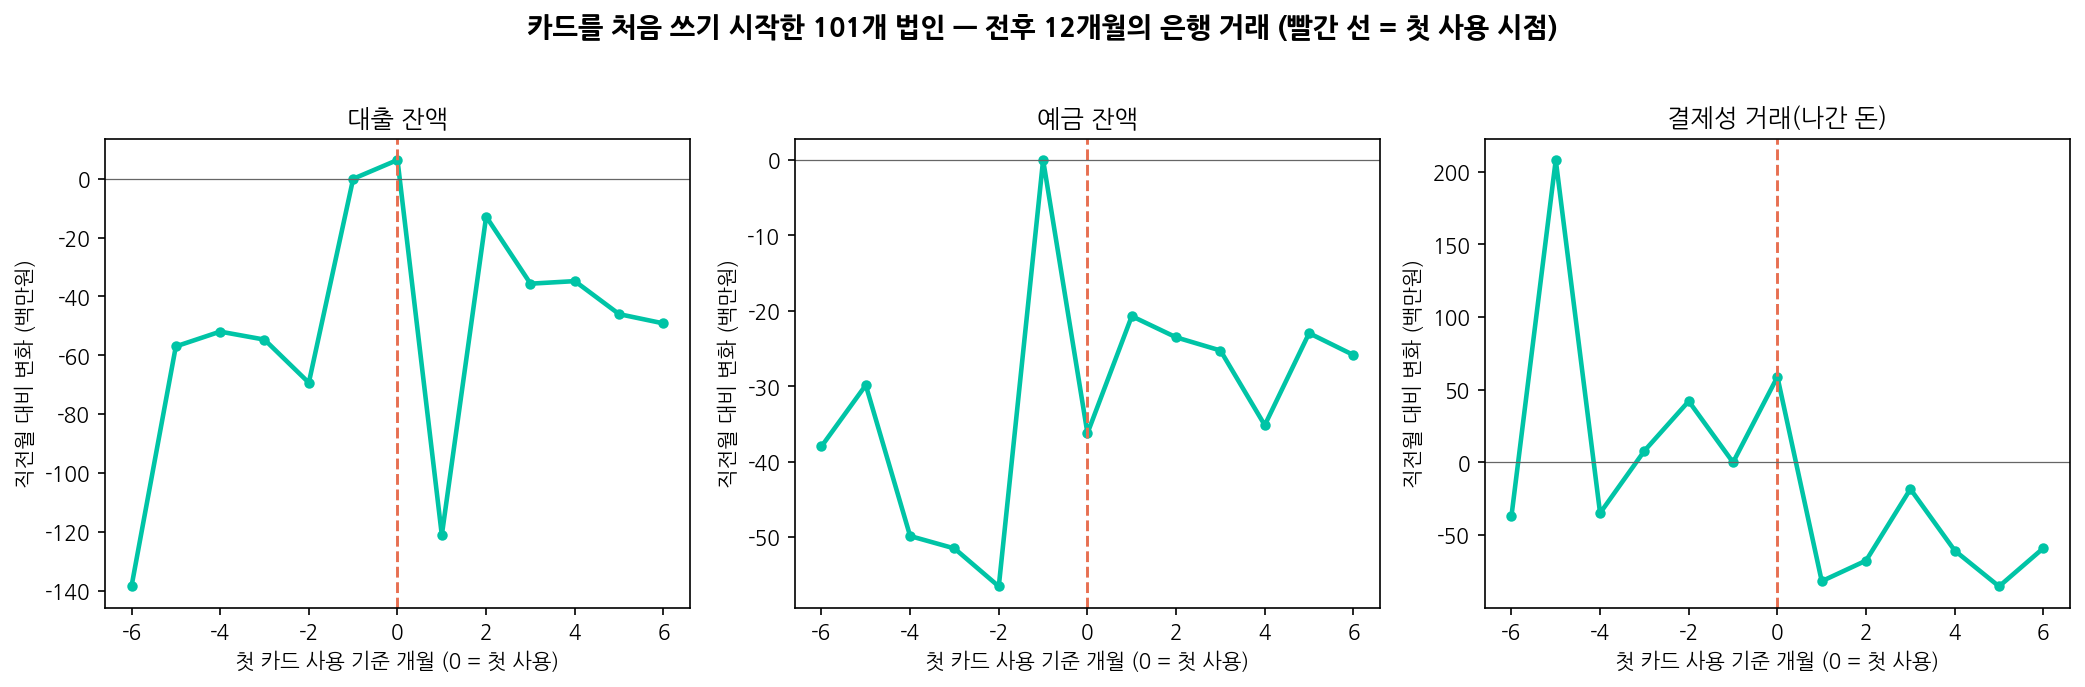

In [11]:
# ============================================================
# ⑤-자연실험: 첫 카드 사용 전후, 은행 거래 3종의 궤적
# ============================================================
months = sorted(d1[YM].unique())
card_mat = d1.pivot_table(index=ID, columns=YM, values=CARD).reindex(columns=months)
active = card_mat > 0
first_idx = np.where(active.values.any(axis=1), active.values.argmax(axis=1), -1)
first_s = pd.Series(first_idx, index=card_mat.index)
late_ids = first_s[(first_s >= months.index(202308)) & first_s.index.isin(user_ids)].index
print(f'후발 활성화 법인: {len(late_ids)}개 (2023.08 이후 처음 카드 사용)')

mats = {m: d1.pivot_table(index=ID, columns=YM, values=m).reindex(columns=months)
        for m in ['총여신', '총수신', '결제성지출']}
offsets = list(range(-6, 7))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, m, ttl in [(axes[0], '총여신', '대출 잔액'), (axes[1], '총수신', '예금 잔액'),
                   (axes[2], '결제성지출', '결제성 거래(나간 돈)')]:
    ys = []
    for k in offsets:
        vals = [mats[m].loc[cid].iloc[t0 + k] - mats[m].loc[cid].iloc[t0 - 1]
                for cid, t0 in first_s[late_ids].items()
                if 0 <= t0 + k < 36 and t0 - 1 >= 0]
        ys.append(np.nanmean(vals))
    ax.plot(offsets, ys, marker='o', ms=4, lw=2.2, color=IM['민트'])
    ax.axvline(0, color=IM['코랄'], ls='--', lw=1.4)
    ax.axhline(0, color=IM['그레이'], lw=0.6)
    ax.set_xlabel('첫 카드 사용 기준 개월 (0 = 첫 사용)')
    ax.set_ylabel('직전월 대비 변화 (백만원)')
    ax.set_title(ttl, fontsize=12)
fig.suptitle(f'카드를 처음 쓰기 시작한 {len(late_ids)}개 법인 — 전후 12개월의 은행 거래 (빨간 선 = 첫 사용 시점)',
             y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

총여신   : 활성화 직전 6개월 증가 비율 20.8% vs 평상시(무사용군 임의 시점) 7.8% — ×2.7
총수신   : 활성화 직전 6개월 증가 비율 52.5% vs 평상시(무사용군 임의 시점) 40.0% — ×1.3
결제성지출 : 활성화 직전 6개월 증가 비율 42.6% vs 평상시(무사용군 임의 시점) 40.5% — ×1.1


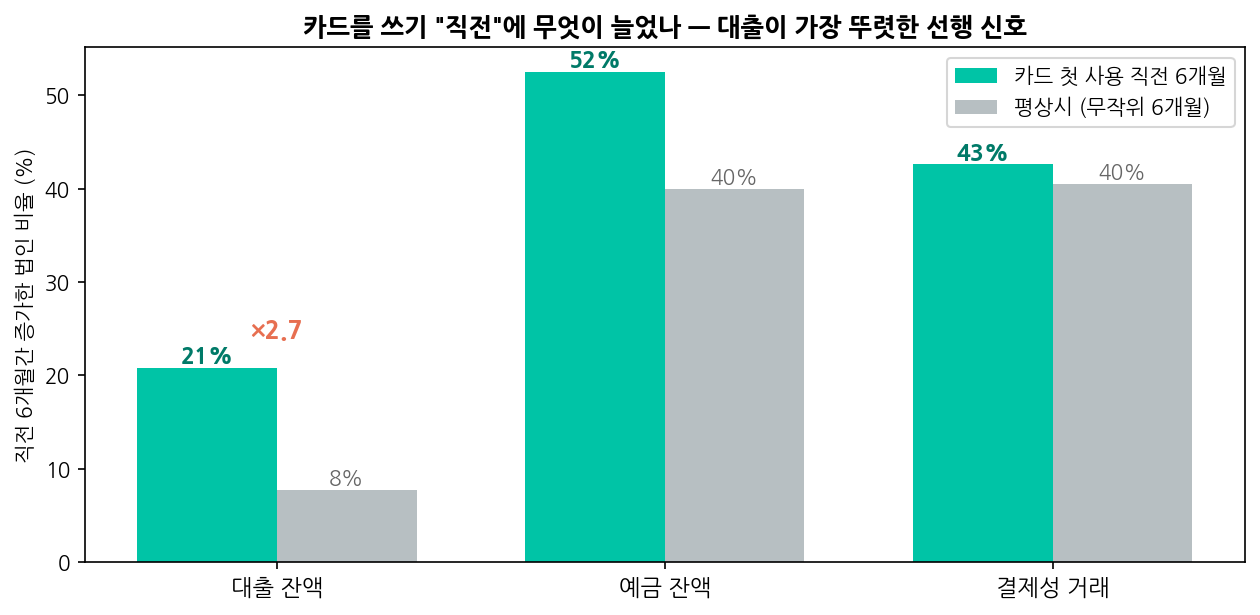

In [12]:
# ============================================================
# ⑤-정량화: "직전 6개월간 늘었나" — 3개 지표 × (활성화군 vs 평상시)
# ============================================================
rng = np.random.RandomState(SEED)
base_pool = [(cid, rng.randint(8, 35)) for cid in rng.choice(sorted(zero_ids), 400, replace=False)]

rows = {}
for m in ['총여신', '총수신', '결제성지출']:
    act = np.mean([mats[m].loc[cid].iloc[t0 - 1] > mats[m].loc[cid].iloc[t0 - 7]
                   for cid, t0 in first_s[late_ids].items() if t0 - 7 >= 0])
    base = np.mean([mats[m].loc[cid].iloc[t0 - 1] > mats[m].loc[cid].iloc[t0 - 7]
                    for cid, t0 in base_pool])
    rows[m] = (act, base)
    print(f'{m:6s}: 활성화 직전 6개월 증가 비율 {act:.1%} vs 평상시(무사용군 임의 시점) {base:.1%} — ×{act / base:.1f}')

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(3)
ax.bar(x - 0.18, [rows[m][0] * 100 for m in rows], 0.36, color=IM['민트'], label='카드 첫 사용 직전 6개월')
ax.bar(x + 0.18, [rows[m][1] * 100 for m in rows], 0.36, color=IM['중립'], label='평상시 (무작위 6개월)')
for i, m in enumerate(rows):
    act, base = rows[m]
    ax.text(i - 0.18, act * 100 + 0.5, f'{act:.0%}', ha='center', fontsize=11, fontweight='bold', color=IM['딥민트'])
    ax.text(i + 0.18, base * 100 + 0.5, f'{base:.0%}', ha='center', fontsize=10, color=IM['그레이'])
    if act / base >= 1.8:
        ax.text(i, max(act, base) * 100 + 3.2, f'×{act / base:.1f}', ha='center', fontsize=12,
                color=IM['코랄'], fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['대출 잔액', '예금 잔액', '결제성 거래'], fontsize=11)
ax.set_ylabel('직전 6개월간 증가한 법인 비율 (%)')
ax.set_title('카드를 쓰기 "직전"에 무엇이 늘었나 — 대출이 가장 뚜렷한 선행 신호', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

### ⑤ 정리 — 타이밍의 근거

- 카드를 처음 쓰기 시작한 법인들은 **직전 6개월에 대출이 늘어난 비율이 평상시의 2배 이상**이었습니다 (대조군은 무작위 표본이라 실행마다 2.5~2.7배 사이에서 소폭 변동).
- 궤적 그래프에서도 대출·결제성 거래가 **첫 사용 "이전"부터** 함께 올라갑니다 — 사업이 커지는 국면에서 카드 수요가 함께 생긴다는 뜻.
- 예금은 뚜렷한 선행 신호가 아닙니다 → 모니터링 대상은 **여신 이벤트**로 좁힐 수 있습니다.

**실행 규칙: "대출 신규·증액 후 4주 안에 카드를 제안한다."** 아무 때나 접촉하는 것보다 명확히 유리한 타이밍입니다.

---

# 최종 요약 — 한 장

**스토리 5줄:**
1. 552개는 유령이 아니다 — **관계(대출 95.5% 보유)와 현금흐름(월 2,700만원 지출)이 살아있는** "카드만 안 쓰는" 반쪽 고객이다.
2. 안 쓰는 이유는 두 갈래 — 부동산업은 **구조적 미수요**(3곳 중 1곳 무사용), 제조·건설은 **습관적 미사용**(전환 가능).
3. 얼마나 쓸지는 **쌍둥이에게 물었다** — 잣대(채널 4개)·쌍둥이 수(k=10)·확실 기준(합의도+거리) 세 결정 모두 정답을 아는 사용군 모의고사로 정했다.
4. **확실 286개만 공식 인용: 잠재 연 59억원(보수 36억)** — 현 시장의 ~5% 증분, 상위 30개가 41%.
5. 타이밍은 **대출 이벤트 직후 4주** — 자연실험에서 대출만이 뚜렷한 선행 신호였다.

**정직한 한계 3가지 (인용 시 반드시 병기):**
- 기대액은 "전환 성공 시" 상한 — 전환 확률(발급 거절, 타행 카드)은 데이터에 없음. 그래서 전환율 시나리오를 병기했다.
- 확실 등급이 보증하는 건 **순서**다. 개별 금액 오차는 ±50% — "이 법인이 상위권"까지만 믿을 것.
- 가상·표본 데이터라 절대금액은 실전과 다를 수 있음 — 실제 적용 시 동일 파이프라인을 실데이터로 재실행.
